# Insight 3: estado civil e ingreso mensual

El estado civil presenta diferencias en la composicion de los tramos de ingreso. Este analisis mide los porcentajes dentro de cada grupo, evitando comparar solo conteos absolutos, y evalua si la asociacion es estadisticamente significativa. No permite concluir causalidad.

In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

ruta_dataset = Path('..') / 'data' / 'online food delivery dataset.csv'
df = pd.read_csv(ruta_dataset)
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
df = df.apply(
    lambda columna: columna.str.strip()
    if pd.api.types.is_string_dtype(columna.dtype)
    else columna
)

tabla = pd.crosstab(df['Marital Status'], df['Monthly Income'])
porcentajes = pd.crosstab(df['Marital Status'], df['Monthly Income'], normalize='index').mul(100)
display(tabla)
display(porcentajes.round(1))

Monthly Income,10001 to 25000,25001 to 50000,Below Rs.10000,More than 50000,No Income
Marital Status,,,,,
Married,13,36,4,43,12
Prefer not to say,2,3,2,4,1
Single,30,30,19,15,174


Monthly Income,10001 to 25000,25001 to 50000,Below Rs.10000,More than 50000,No Income
Marital Status,,,,,
Married,12.0,33.3,3.7,39.8,11.1
Prefer not to say,16.7,25.0,16.7,33.3,8.3
Single,11.2,11.2,7.1,5.6,64.9


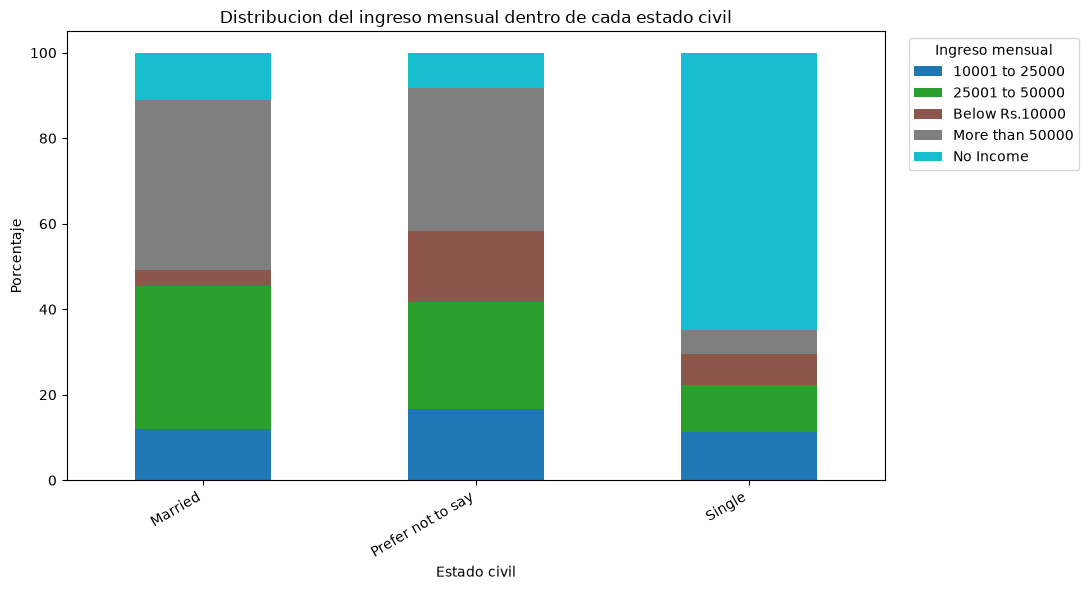

In [5]:
ax = porcentajes.plot(kind='bar', stacked=True, figsize=(11, 6), colormap='tab10')
ax.set_title('Distribucion del ingreso mensual dentro de cada estado civil')
ax.set_xlabel('Estado civil')
ax.set_ylabel('Porcentaje')
ax.legend(title='Ingreso mensual', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [6]:
chi2, p_valor, grados_libertad, esperadas = chi2_contingency(tabla)
n = tabla.to_numpy().sum()
filas, columnas = tabla.shape
phi2 = chi2 / n
phi2_corregido = max(0, phi2 - ((columnas - 1) * (filas - 1)) / (n - 1))
filas_corregidas = filas - ((filas - 1) ** 2) / (n - 1)
columnas_corregidas = columnas - ((columnas - 1) ** 2) / (n - 1)
v_cramer = (phi2_corregido / max(1, min(columnas_corregidas - 1, filas_corregidas - 1))) ** 0.5
print(f'Chi-cuadrado: {chi2:.3f} | gl: {grados_libertad} | p-valor: {p_valor:.6g}')
print(f"V de Cramer (corregida): {v_cramer:.3f}")
print('Asociacion estadisticamente significativa (alpha=0.05).' if p_valor < 0.05 else 'No se detecta asociacion estadisticamente significativa (alpha=0.05).')

Chi-cuadrado: 134.355 | gl: 8 | p-valor: 3.53371e-25
V de Cramer (corregida): 0.405
Asociacion estadisticamente significativa (alpha=0.05).


,variable,tipo_analitico,dtype_pandas,categorias_observadas
0,Marital Status,Categórica nominal,str,"[Married, Prefer not to say, Single]"
1,Monthly Income,Categórica ordinal (tramos de ingreso),str,"[10001 to 25000, 25001 to 50000, Below Rs.1000..."


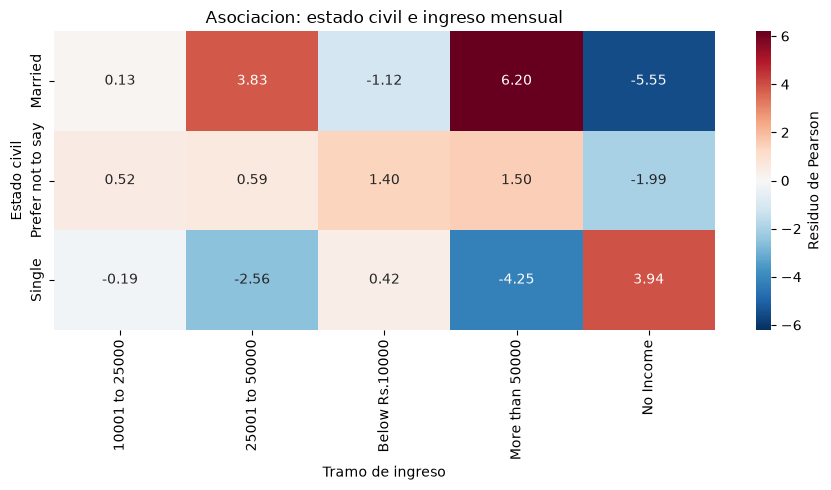

V de Cramer corregida: 0.405
Residuo positivo: combinacion mas frecuente de lo esperado bajo independencia.


In [7]:
import numpy as np
import seaborn as sns

variables = ["Marital Status", "Monthly Income"]
tipos = ["Categórica nominal", "Categórica ordinal (tramos de ingreso)"]
resumen_tipos = pd.DataFrame(
    {
        "variable": variables,
        "tipo_analitico": tipos,
        "dtype_pandas": [str(df[variable].dtype) for variable in variables],
        "categorias_observadas": [
            sorted(df[variable].dropna().unique().tolist())
            for variable in variables
        ],
    }
)
display(resumen_tipos)

_, _, _, esperadas_heatmap = chi2_contingency(tabla, correction=False)
residuos_pearson = (tabla - esperadas_heatmap) / np.sqrt(esperadas_heatmap)
limite_color = max(abs(residuos_pearson.to_numpy()).max(), 1)
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    residuos_pearson,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-limite_color,
    vmax=limite_color,
    cbar_kws={"label": "Residuo de Pearson"},
    ax=ax,
)
ax.set_title("Asociacion: estado civil e ingreso mensual")
ax.set_xlabel("Tramo de ingreso")
ax.set_ylabel("Estado civil")
plt.tight_layout()
plt.show()
print(f"V de Cramer corregida: {v_cramer:.3f}")
print("Residuo positivo: combinacion mas frecuente de lo esperado bajo independencia.")